# Lab 1 Distributions

### 1. Generating Exponential Random Variables and Visualizing the Distribution

**Exercise Questions:**

1.1 Modify the provided code to accept user input for the scale parameter $ \lambda $ of the exponential distribution and the number of random variables to generate. Run the code with different input values and observe how the mean and variance change.

As $ \lambda $ is increased, the mean and variance both become lower. This is because the distribution becomes more tightly "squished" towards the Y axis and the mean value becomes smaller. Because it get's more "squished" and tightly packed, the variance also lowers.

When the number of random variables increases, the histogram becomes smoother and the mean and variance will converge to their theoretical values.

1.2 Explain the significance of the scale parameter $ \lambda $ in the exponential distribution and how it affects the shape of the distribution.

The scale parameter of an exponential function defines the average number of events per unit of time or space. It determines how quick probabilities decrease for longer times, or the decay of the PDF (how steep the curve is). As just previously mentioned, the scale parameter defines the Y intercept of the distribution, but of course the area under the curve needs to be 1, so for higher $ \lambda $ the distribution is very tightly packed to the Y axis and drops off extremely fast to maintain the total area of 1. For lower $ \lambda $ we can see a much "flatter" distribution, still with the same general exponential drop shape but spread out more.

1.3. What does the mean and variance of the exponential random variables represent in the context of the distribution? How do these statistical measures relate to the scale parameter $ \lambda $?

In the context of the distribution, the mean represents the average or expected X value when weighted by the probability of each value occurring, this is usally used to model average waiting times until an event. We know that $\mu = \frac{1}{\lambda}$.

The variance represents the spread of waiting times around the mean, i.e how tightly packed they are near the mean. As $ \lambda $ is increased, the mean and variance both become lower. This is because the distribution becomes more tightly "squished" towards the Y axis and the mean value becomes smaller. Because it get's more "squished" and tightly packed, the variance also lowers. Vice versa, if $ \lambda $ is decreased, the mean and variance increase.

1.4. Compare the histogram of the generated exponential random variables with the theoretical exponential probability density function (PDF). Discuss any similarities or differences between the two plots.

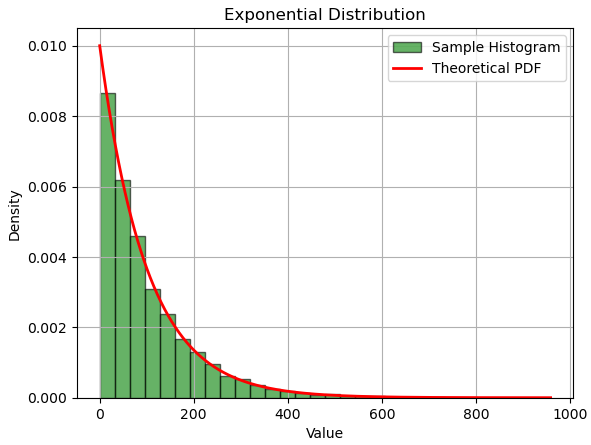

For high samples (>10000) there is almost no discernible difference between the plots, which is to be expected as we are conducting independent trials and the average result will approach the theoretical. For low samples (<1000) there can be significant differences (higher or lower instances of an X value) but it is quite random of course. Once major difference is that the theoretical PDF approaches infinity, which cannot be represented using finite samples.

1.5. Experiment with different values for the scale parameter $ \lambda $ and the number of random variables to generate. How do changes in these parameters influence the shape and spread of the exponential distribution?

As $ \lambda $ is increased, the mean and variance both become lower. The distribution becomes more tightly "squished" towards the Y axis and has a lower spread over the X values, and so the mean value becomes smaller. Because it gets more "squished" and tightly packed, the variance also lowers. Vice versa, if $ \lambda $ is decreased, the mean and variance increase.

Raising the number of samples doesn't affect the theoretical PDF, but it allows the generated histogram of trials to approach the theoretical PDF, and becomes almost exact for high samples (>10000)

1.6. Explore the relationship between the mean, variance, and scale parameter of the exponential distribution. How are these quantities related mathematically, and how do they manifest in the generated random variables?

The mean and variance can be found from $ \lambda $. The mean $ \mu = \frac{1}{\lambda}$ and the variance $ \sigma = \frac{1}{\lambda^2}$, this is how they are mathamatically related.

They manifest in the histogram as I have already explained, a lower mean means the average value is lower and so the distribution is packed more towards the Y axis. Variance manifests in how tight the distribution is packed around the mean (higher or lower spread).


Results:
Manual Mean: 100.22392389665426
Manual Variance: 10151.121308752026
Numpy Mean: 100.22392389665426
Numpy Variance: 10151.121308752026
Theoretical Mean (1/λ): 100.0
Theoretical Variance (1/λ²): 10000.0


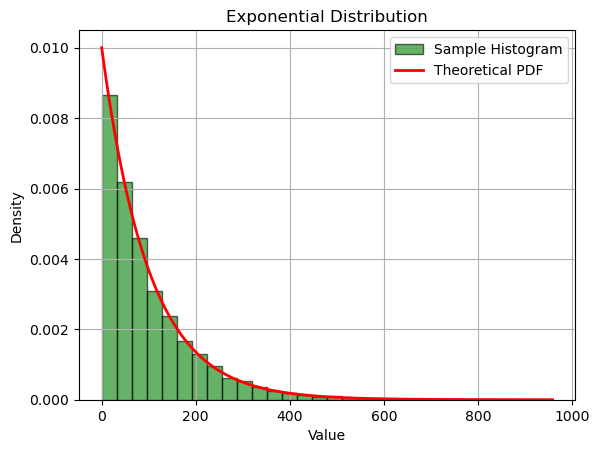

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Get user input
# scale_parameter = float(input("Enter the rate parameter  (lambda) for the exponential distribution: "))
scale_parameter = 0.01
# num_samples = int(input("Enter the number of exponential random variables to generate: "))
num_samples = 10000

# Step 2: Generate the exponential random variables
exponential_rvs = np.random.exponential(scale=1/scale_parameter, size=num_samples)

# TODO: Step 3 - Manually calculate the mean and variance
# Hint: Use the formula for mean = sum of all values / number of values
# And variance = average of squared differences from the mean

# YOUR CODE HERE ↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓↓

# Calculate mean
manual_mean = np.sum(exponential_rvs) / num_samples

# Calculate variance
squared_diffs = (exponential_rvs - manual_mean) ** 2
manual_variance = np.sum(squared_diffs) / num_samples
# ↑↑↑↑↑↑↑↑↑↑↑↑↑↑↑↑↑↑↑↑↑↑↑↑↑↑↑↑↑↑↑↑↑↑↑↑↑↑↑↑↑↑↑↑↑↑↑↑↑↑

# Step 4: Compare with numpy's built-in results and theoretical values
print("\nResults:")
print("Manual Mean:", manual_mean)
print("Manual Variance:", manual_variance)
print("Numpy Mean:", np.mean(exponential_rvs))
print("Numpy Variance:", np.var(exponential_rvs))
print("Theoretical Mean (1/λ):", 1/scale_parameter)
print("Theoretical Variance (1/λ²):", 1/(scale_parameter**2))

# Step 5: Plot histogram and theoretical PDF
plt.hist(exponential_rvs, bins=30, density=True, alpha=0.6, color='g', edgecolor='black', label='Sample Histogram')

x = np.linspace(0, np.max(exponential_rvs), 1000)
plt.plot(x, scale_parameter * np.exp(-scale_parameter * x), 'r-', lw=2, label='Theoretical PDF')

plt.title('Exponential Distribution')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.show()



### 2. Creating Gaussian distribution from the sum of exponential random variables
According to the central limit theorem, the sum of a large number of independent, identically distributed random variables tends toward a Gaussian distribution, regardless of the distribution of the individual random variables.

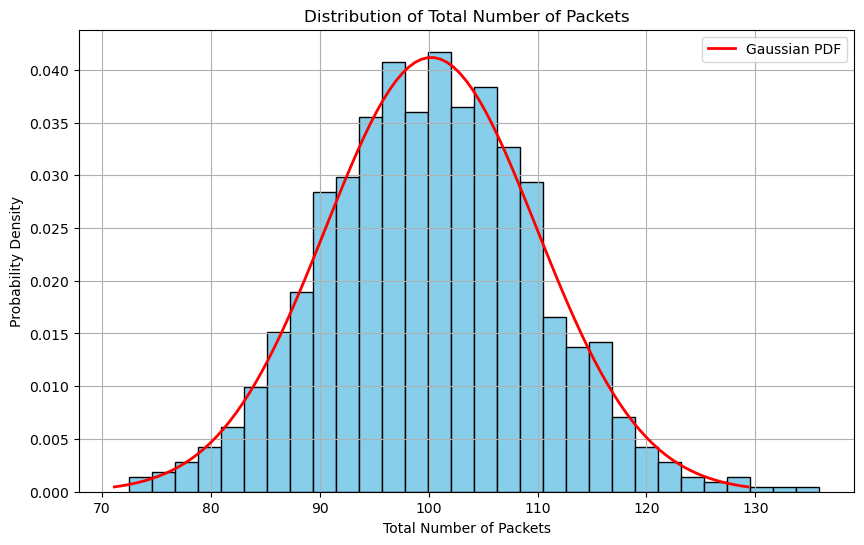

In [187]:
import numpy as np
import matplotlib.pyplot as plt

def generate_packets(num_generators, num_packets_per_generator,lambda_param):
    """
    Simulate packet generation from multiple generators.
    """
    packets = np.zeros(num_packets_per_generator)
    for _ in range(num_generators):
        generator_packets = np.random.exponential(scale=1/lambda_param, size=num_packets_per_generator)
        packets += generator_packets 
    return packets

def calculate_mean_and_variance(packets):
    """
    Write code to Calculate the mean and variance of the total number of packets.
    "" YOUR CODE HERE"""
    
    mean = np.mean(packets)
    variance = np.var(packets)
    return mean, variance

def plot_distribution(packets):
    """
    Plot the distribution of the total number of packets.
    """
    plt.figure(figsize=(10, 6))
    plt.hist(packets, bins=30, density=True, color='skyblue', edgecolor='black')
    
    # Plot the Gaussian distribution with the same mean and variance
    mean, variance = calculate_mean_and_variance(packets)
    sigma = np.sqrt(variance)
    x = np.linspace(mean - 3*sigma, mean + 3*sigma, 100)
    plt.plot(x, 1/(sigma * np.sqrt(2 * np.pi)) * np.exp(- (x - mean)**2 / (2 * sigma**2)), color='red', lw=2, label='Gaussian PDF')
    
    plt.title('Distribution of Total Number of Packets')
    plt.xlabel('Total Number of Packets')
    plt.ylabel('Probability Density')
    plt.legend()
    plt.grid(True)
    plt.show()

# Simulation parameters
# num_generators = int(input("Enter the number of generators (information sources): ")) # e.g., 1000
num_generators = 100
# num_packets_per_generator  = int(input("Enter the number of packets per generator (information source): ")) #e.g., 1000
num_packets_per_generator = 1000
# lambda_param = float(input("Enter the rate parameter λ (lambda > 0): "))
lambda_param = 1


# Generate packets from multiple generators
packets = generate_packets(num_generators, num_packets_per_generator,lambda_param)

# Plot the distribution of the total number of packets
plot_distribution(packets)


**Exercise Questions:**

1. **Understanding Packet Generation Simulation**:
    - What distribution is used to model the inter-arrival times of packets in each generator? How is this distribution parameterized?
    
    An exponential distribution is used to model the inter-arrival times. It is parameterised by the scale parameter $ \lambda $.

    - Explain how the `calculate_mean_and_variance` function computes the mean and variance of the total number of packets.

    It uses the numpy libraries functions np.mean and np.var. Under the hood the mean function sums and divides by the number of sample, and the var function finds the squared difference of each sample and the mean, sums them and then divides by the number of samples.

2. **Parameter Exploration**:
    - Experiment with different values of `num_generators` and `num_packets_per_generator` and `Lambda` . How does changing these parameters affect the distribution of the total number of packets? When does the total packet distribution start to look normal?

    As num_generators is increased, we see that it is linearly related to the mean number of packets. Raising num_generators also increases the variance of the experimental histogram.

    As we raise num_packets_per_generator, it does not affect the mean or variance, but it does allow the histogram of the packets to approach the theoretical gaussian distribution.

    As lambda is raised, the variance of the experimental histogram is decreased, and the mean is increased as packets are being received more frequently.

    The only variable that affects whether or not the total packet distribution looks "normal" is the num_packets_per_generator. It can start to look normal around num_packets_per_generator=100, but looks very good starting around 1000 and up. (first image 100, second image 1000)
    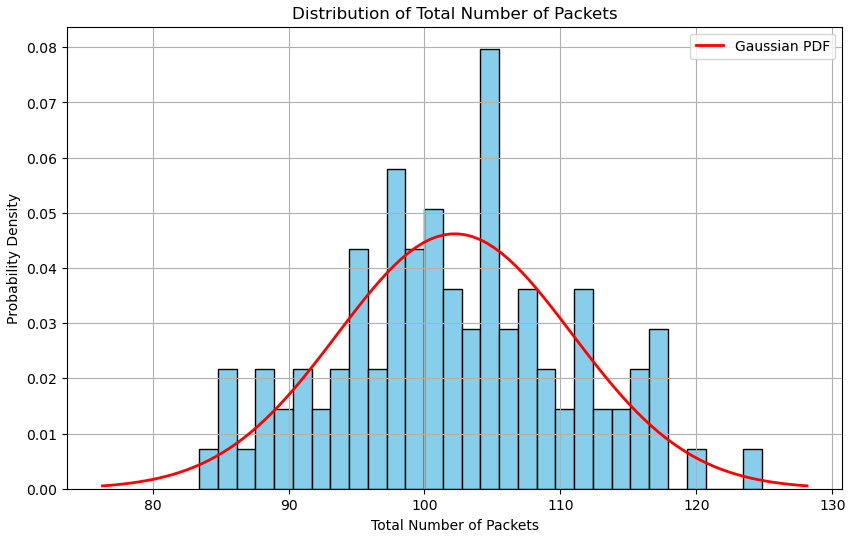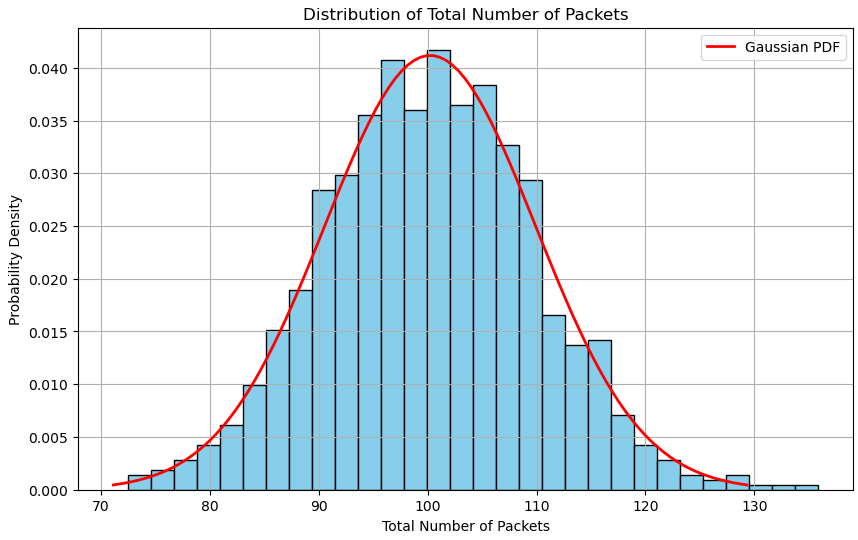

    - Investigate the impact of varying the scale parameter of the exponential distribution used in `generate_packets`. How does adjusting this parameter influence the shape and characteristics of the packet distribution?

3. **Comparison with Gaussian Distribution**:
    - Discuss the rationale behind overlaying the Gaussian (normal) distribution on the histogram of total packet counts. What does this comparison reveal about the distribution of total packets?

    We overlay the normal distribution on the histogram in order to compare the two, and so we can see the central limit theorem in practice as we increase the number of packets. It reveals that that the distribution of total packets follows a normal distribution.

    - Analyze the behavior of the Gaussian distribution relative to the packet distribution. Under what conditions does the Gaussian distribution provide a good approximation of the packet distribution?

    In order for the gaussian distribution to be a good approximation of the packet distribution, we need a large number of packets per generator. The number of generators and lambda affect the shape and position of the distribution, but according to the central limit theorem, the distribution will tend towards gaussian if there is a LARGE number of independent, identically distributed trials (packet arrivals).
   
4. **Real-world Application**:
    - Translate the insights gained from the packet generation simulation into practical recommendations for network administrators or system designers. Discuss how the observed packet distribution characteristics could inform decisions related to network capacity planning, resource allocation, or traffic management strategies in real-world scenarios. Provide specific examples or case studies to illustrate the potential impact of these recommendations.

    Traffic is allocated randomly and when you aggregate it it becomes Gaussian, which has practical use cases. For capacity planning, admins can model aggregate traffic using a mean and variance rather than worst-case bursts. For example, if average load is 600 Mbps with known variance, links can be designed to handle mean + 2–3*$\sigma$, achieving high utilisation without excessive overprovisioning.

    For resource allocation, buffers and queues can be sized based on statistical overflow risk instead of being fixed. This improves efficiency in routers and switches, especially in data centres. In traffic management, quality of service policies can exploit this predictability, so scheduling algorithms can assume mean flows with some variance, reducing jitter.

    A real-world example is cloud providers dynamically allocate bandwidth based on expected normal distributions with a mean and variance, improving utilisation while maintaining guaranteed throughput.

### 3. Relationship between Binomial and Normal Distributions
The binomial random variable (RV) is a discrete random variable, as it represents the number of successes in a fixed number of $n$ independent Bernoulli trials, each with the same probability of success p. 

For a binomial random variable $X$ with $n$ trials and probability of success $p$ on each trial:
    - The mean $\mu$ is given by $np$.
    - The standard deviation $\sigma$ is given by $\sqrt{np(1-p)}$.
- When $n$ is sufficiently large, the binomial distribution can be approximated by the normal distribution with
  mean $\mu$ and standard deviation $\sigma$.
- This approximation simplifies calculations and allows us to leverage properties of the normal distribution to 
  analyze the binomial distribution.

Mean = 15.0 and Variance = 7.5


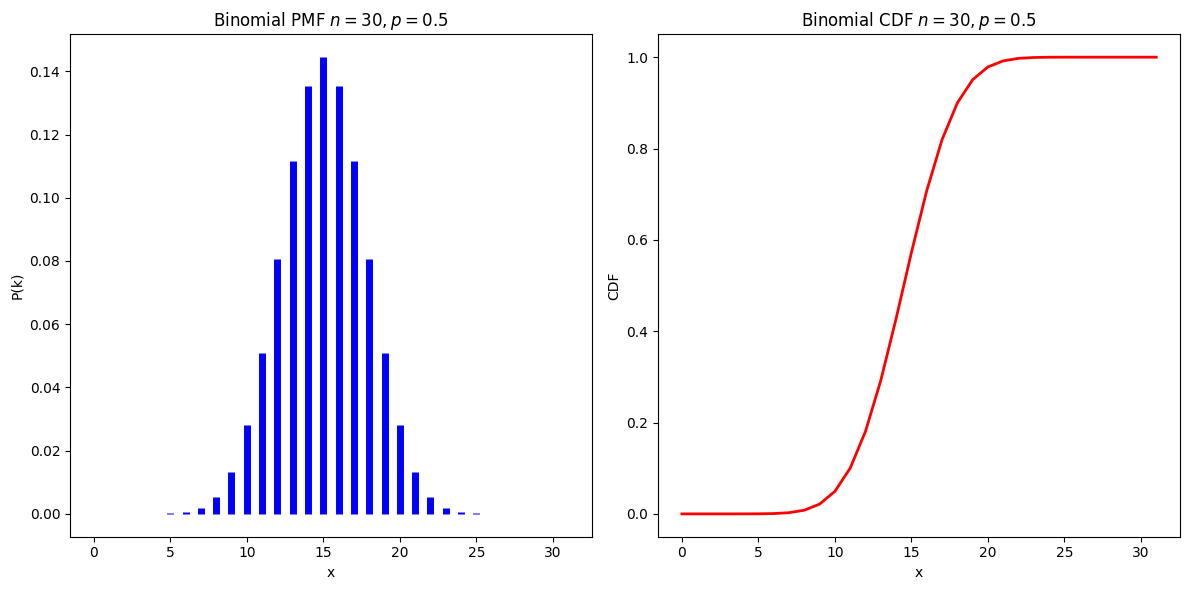

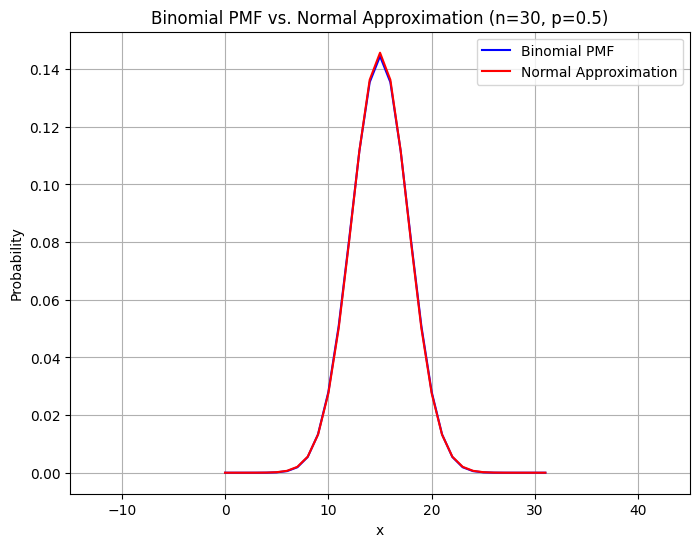

In [7]:
# Original- Copyright 2014 Dr. Greg M. Bernstein
""" A simple script to show how to get and use discrete random variable distributions from SciPy."""
#Extended - Copyright 2024 Dr Gayathri Kongara

import numpy as np
from scipy.stats import binom, norm
import matplotlib.pyplot as plt


# User input for n and p
# n = int(input("Enter the number of trials (n): "))
n = 30
# p = float(input("Enter the probability of success on each trial (p): "))
p = 0.5


# Creating a Binomial random variable with n and p
binom_rv = binom(n, p)

# Mean and Variance of the binomial distribution
print("Mean = {} and Variance = {}".format(binom_rv.mean(), binom_rv.var()))

# Generate random samples
samps = binom_rv.rvs(size=100)

# Plot the probability mass function (PMF)
x = np.arange(0, n + 2)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Plot PMF
ax1.vlines(x, 0, binom_rv.pmf(x), 'b', lw=5)
ax1.set_title("Binomial PMF $n={}, p={}$".format(n, p))
ax1.set_ylabel("P(k)")
ax1.set_xlabel("x")

# Plot CDF
ax2.plot(x, binom_rv.cdf(x), 'r-', lw=2)
ax2.set_title("Binomial CDF $n={}, p={}$".format(n, p))
ax2.set_ylabel("CDF")
ax2.set_xlabel("x")

plt.tight_layout()
plt.show()

# Investigate the relationship between the binomial distribution and the normal approximation for large n

mu = n * p
sigma = np.sqrt(n * p * (1 - p))
norm_approx = norm(mu, sigma)

    # Plot both distributions
plt.figure(figsize=(8, 6))
plt.plot(x, binom_rv.pmf(x), 'b', label='Binomial PMF')
plt.plot(x, norm_approx.pdf(x), 'r', label='Normal Approximation')
plt.xlim(mu-30, mu+30)  # Adjust the x-axis limits to display around mean
plt.title("Binomial PMF vs. Normal Approximation (n={}, p={})".format(n, p))
plt.xlabel("x")
plt.ylabel("Probability")
plt.legend()
plt.grid(True)
plt.show()



#### Exercise Questions
The code takes user input for the number of trials $ n $ and the probability of success $ p $ on each trial. Provide appropriate inputs for $ n $ and $ p $ to generate two scenarios

- 3.1 For n , choose different values of p to plot a case when the Binomial PMF approximates a Normal distribution.
Using n = 30, I found that when p is around 0.5, the binomial PMF approximates the normal distribution very well.
- 3.2 For n , choose different values of p to plot a case when the Binomial PMF deviates from a Normal distribution.
Using n = 30, I found that when p is close to 1 or 0, the approximation is not as good.

For each of the above scenarios generate the below graphs with

 **1. PMF Plot**: Plot the probability mass function (PMF) of the binomial distribution.

 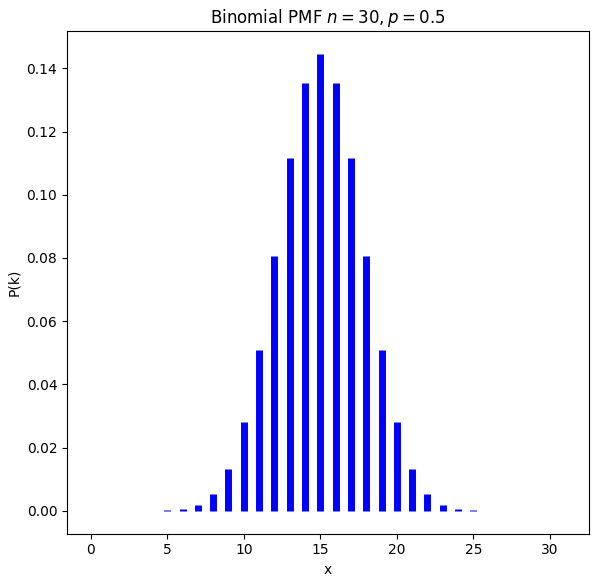
 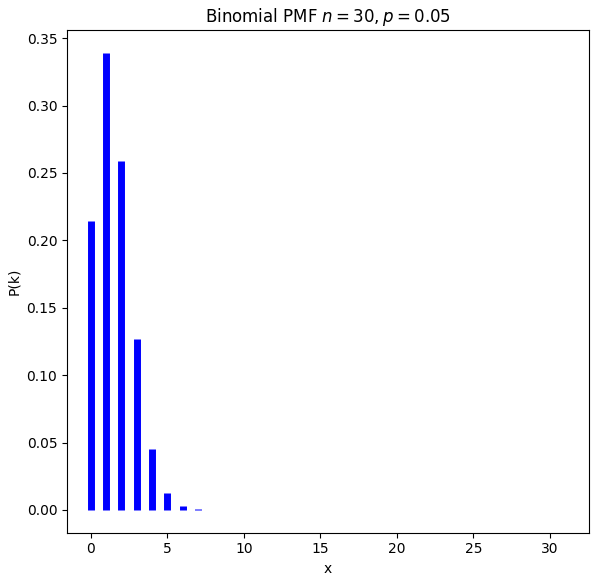

 **2. CDF Plot**: Plot the cumulative distribution function (CDF) of the binomial distribution.

 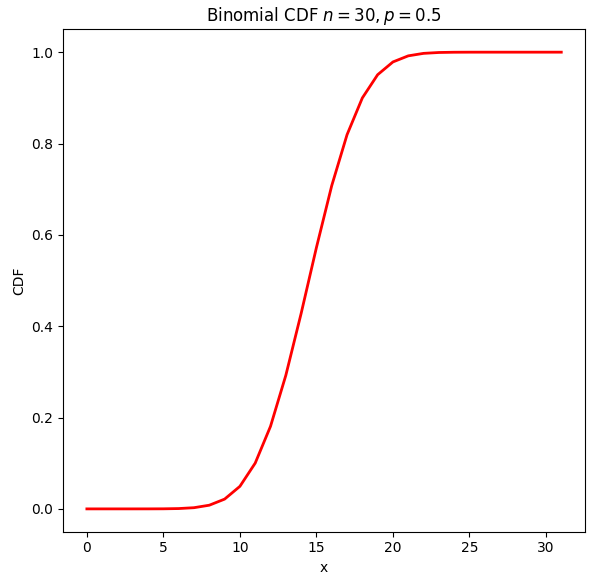
 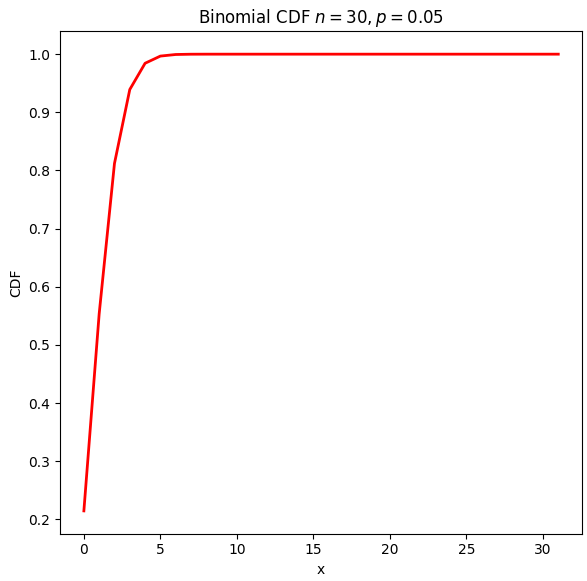

 **3. Normal Approximation**: If $ n $ is sufficiently large ($ n \geq 30 $), generate the normal approximation to the binomial distribution using the mean $ \mu = n \times p $ and standard deviation $ \sigma = \sqrt{n \times p \times (1 - p)} $. Plot both the binomial PMF and the normal approximation PDF on the same graph for comparison.

 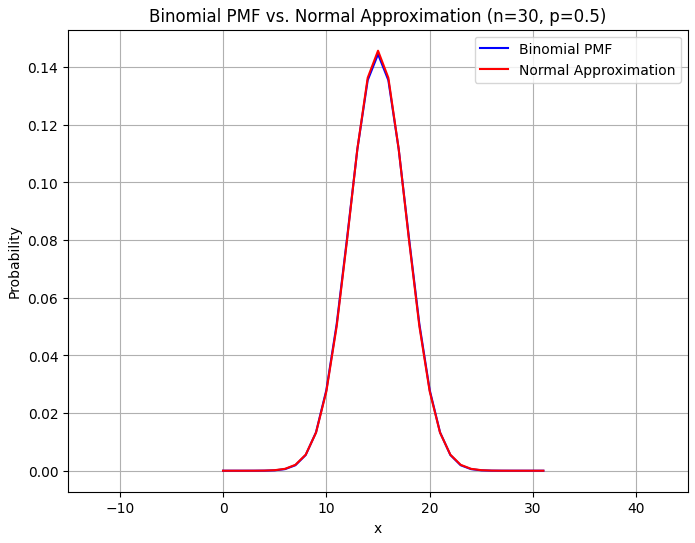
 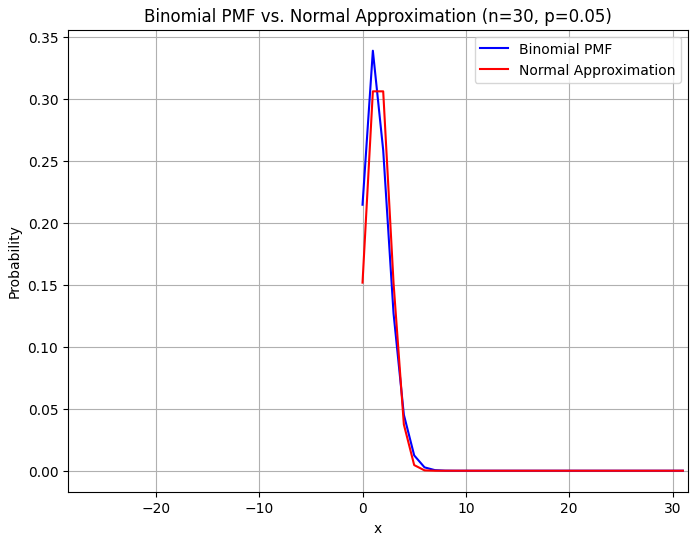



### 4. When is Poisson distribution a good approximation of the binomial distribution?

The Poisson distribution is often used as an approximation to the Binomial distribution in situations where the number of trials (\( n \)) is very large and the probability of success (\( p \)) is very small. Here are some advantages of using the Poisson approximation:

##### Binomial Distribution

The binomial distribution describes the number of successes in a fixed number of independent Bernoulli trials (each with the same probability of success). It does not exhibit the memoryless property because:

- **Dependence on Number of Trials**: The binomial distribution depends on the number of trials \(n\) and the probability of success \(p\). The probability of a certain number of successes is influenced by the total number of trials.

- **No Memorylessness**: The probability of achieving a certain number of successes in additional trials is not independent of the number of trials already performed. For instance, if you have already observed a certain number of successes, it affects the probability of further successes. Memorylessness is a very useful property that simplifies analytical modelling of network traffic. This memorylessness property in the context of network traffic implies that the future packet arrival times do not depend on past arrivals.


1. **Simplicity**: The Poisson distribution has a simpler form compared to the Binomial distribution, which involves calculating binomial coefficients. This simplicity makes it easier to work with mathematically and computationally.

2. **Computationally Efficient**: Calculating probabilities with the Poisson distribution is generally computationally less intensive compared to the Binomial distribution, especially for large values of \( n \).

3. **Memory Efficiency**: The Poisson distribution requires less memory to store probabilities compared to the Binomial distribution, especially for large \( n \).

4. **Approximation for Rare Events**: The Poisson distribution is well-suited for modeling rare events where the probability of success on each trial is very small. In such cases, the Binomial distribution with a large number of trials (\( n \)) and a small probability of success (\( p \)) can be approximated by a Poisson distribution with parameter \( \lambda = n \cdot p \).

5. **Asymptotic Behavior**: As \( n \) approaches infinity and \( p \) approaches zero while keeping \( n \cdot p = \lambda \) constant, the Binomial distribution converges to the Poisson distribution. This means that for very large \( n \) and very small \( p \), the Binomial distribution behaves similarly to the Poisson distribution.

Overall, the Poisson approximation to the Binomial distribution is advantageous in terms of simplicity, computational efficiency, and memory efficiency, especially for modeling rare events with a large number of trials and a small probability of success.




Recall, the probability mass function (PMF) equations for the Binomial and Poisson distributions:

1. **Binomial Distribution**:
   - The probability mass function (PMF) of a Binomial distribution with parameters \( n \) (number of trials) and \( p \) (probability of success on each trial) is given by:
   $$ P(X=k) = \binom{n}{k} \times p^k \times (1-p)^{n-k} $$
   where:
   - $ k $ is the number of successes,
   - $ \binom{n}{k} $ is the binomial coefficient, calculated as $ \frac{n!}{k!(n-k)!} $, and
   - $ p $ is the probability of success on each trial.

2. **Poisson Distribution**:
   - The probability mass function (PMF) of a Poisson distribution with parameter \( \lambda \) (the average rate of occurrences) is given by:
   $$ P(X=k) = \frac{e^{-\lambda} \times \lambda^k}{k!} $$
   where:
   - $ k $ is the number of occurrences,
   - $ e $ is the base of the natural logarithm (approximately 2.71828), and
   - $ \lambda $ is the average rate of occurrences.
   
   
There is a rule of thumb stating that the Poisson distribution is a good approximation of the binomial distribution if n is at least 20 and p is smaller than or equal to 0.05, and an excellent approximation if n ≥ 100 and np ≤ 10 [https://view.officeapps.live.com/op/view.aspx?src=https%3A%2F%2Fwww.grotto-networking.com%2Ffiles%2FNetDesignCourse%2FRandomVariableReview.pptx&wdOrigin=BROWSELINK]. 

To prove this, lets consider a bit error scenario with a certain probability p and number of trials/number of information bits transmitted n. We will use the code below to demonstrate the equivalence of Poisson and Binomial distributions under certain assumptions namely 

$ n ≥ 100 \\ np ≤ 10 $


**Example Scenario** 

The probability of a bit error occurring on a 10Gbps Ethernet link is $𝑃(bit_{𝑒𝑟𝑟𝑜𝑟} )=1.0×10^{−12}$

#### Questions
4.1. Calculate the number of bits $n_1$ in one second  

10Gbps link, so $n_1$ is $10*10^9$ bits

4.2. Calculate the average number of errors per second $\mu_{sec} = n_1 \cdot p$

$\mu_{sec} = n_1 \cdot p = 10*10^9 * 1.0×10^{−12} = 10*10^{-3} = 0.01$

4.3. Calculate the number of bits $n_2$ in one hour

$n_2 = n_1 * 3600 = 36 * 10^{12}$ bits

4.4. Calculate the average number of errors in one hour $\mu_{hour} = n_2 \cdot p$ 

$\mu_{hour} = n_2 \cdot p = 36 * 10^{12} * 1.0×10^{−12} = 36$




Mean for a second (mu_sec): 100000.00000000001
Mean for an hour (mu_hour): 360000000.0
Creating a Poisson random variable with  and mu_sec = 100000.00000000001
Creating a Binomial random variable for n1 bits/sec having a prob of error p= 10000000000
Creating a Poisson random variable with  and mu_hour = 360000000.0
Creating a Binomial random variable for n1 bits/hour having a prob of error p= 36000000000000
Mean = 100000.00000000001 and Variance = 100000.00000000001


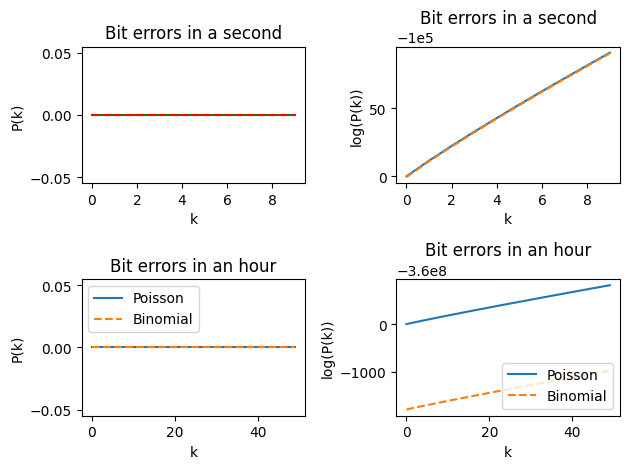

In [12]:
# Copyright 2014 Dr. Greg M. Bernstein
""" A simple script to show how to get and use Poisson and Binomial
    distributions from SciPy. Compares and plots these distributions for
    some interesting parameter values.
"""
# Edited 2024 Dr Gayathri Kongara
import numpy as np
from scipy.stats import binom
from scipy.stats import poisson
import matplotlib.pyplot as plt

if __name__ == '__main__':
    # Case one: n = 1.0e10, p=1.0e-12
    # Case two: n = 3600.0e10, p = 1.0e-12
    # User inputs for n1, n2, and p
    # User inputs for n1, n2, and p
    # n1 = float(input("Enter the number of trials for a second (n1): "))

    n1 = 10 * 10**9
    # n2 = float(input("Enter the number of trials for an hour (n2): "))
    n2 = n1 * 3600
    # p = float(input("Enter the probability of success on each trial (p): "))
    p = 1e-5

    # n1 = 10 * 5
    # n2 = n1 * 3600
    # p = 0.3



    # Calculate mean for a second and an hour
    mu_sec = n1 * p
    mu_hour = n2 * p

    # Display the results
    print("Mean for a second (mu_sec):", mu_sec)
    print("Mean for an hour (mu_hour):", mu_hour)
    print ("Creating a Poisson random variable with  and mu_sec = {}".format(mu_sec))
    rvp = poisson(mu_sec)
    print ("Creating a Binomial random variable for n1 bits/sec having a prob of error p= {}".format(n1))
    rvb = binom(n1, p)
    print ("Creating a Poisson random variable with  and mu_hour = {}".format(mu_hour))
    rvp2 = poisson(mu_hour)
    print ("Creating a Binomial random variable for n1 bits/hour having a prob of error p= {}".format(n2))
    rvb2 = binom(n2, p)
    print ("Mean = {} and Variance = {}".format(rvp.mean(), rvp.var()))

    #samps = rvp.rvs(size=10)  # Generates 10 samples
    #print ("Some samples: {}".format(samps))
    #Display frozen pmf
    x = np.arange(0, 10)
    x2 = np.arange(0, 50)

    # x = np.arange(0, 500)
    # x2 = np.arange(0, 500000)

    # Create a 2 x 2 grid of subplots
    fig, axes = plt.subplots(nrows=2, ncols=2)
    axes[0,0].plot(x, rvp.pmf(x), "g-", x, rvb.pmf(x), "r--")
    axes[0,0].set_ylabel("P(k)")
    axes[0,0].set_xlabel("k")
    axes[0,0].set_title("Bit errors in a second")

    axes[0,1].plot(x, rvp.logpmf(x), "-", x, rvb.logpmf(x), "--")
    axes[0,1].set_ylabel("log(P(k))")
    axes[0,1].set_xlabel("k")
    axes[0,1].set_title("Bit errors in a second")

    axes[1,0].plot(x2, rvp2.pmf(x2), "-", label="Poisson")
    axes[1,0].plot(x2, rvb2.pmf(x2), "--", label="Binomial")
    axes[1,0].set_ylabel("P(k)")
    axes[1,0].set_xlabel("k")
    axes[1,0].set_title("Bit errors in an hour")
    axes[1,0].legend(loc=2)

    axes[1,1].plot(x2, rvp2.logpmf(x2), "-", label="Poisson")
    axes[1,1].plot(x2, rvb2.logpmf(x2),"--", label="Binomial")
    axes[1,1].set_ylabel("log(P(k))")
    axes[1,1].set_xlabel("k")
    axes[1,1].set_title("Bit errors in an hour")
    axes[1,1].legend(loc=4)
    fig.tight_layout()
    plt.show()


#### Questions
4.5. Comment on the similarity/differences of the probability of bit error distributions obtained over a second and over an hour. 

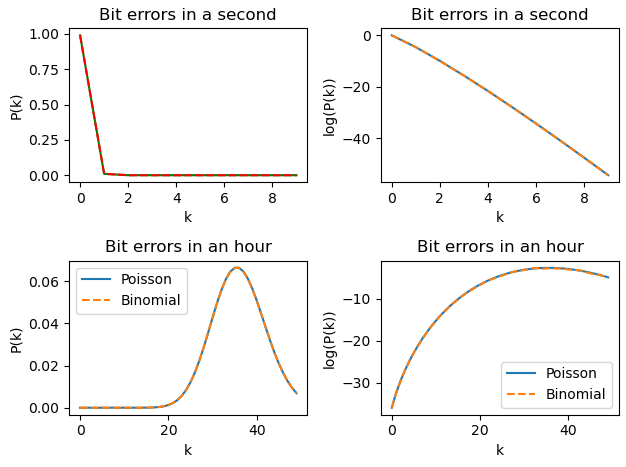

There is really nothing similar at all about the distributions. For the case of one second, the most common number of bits is 0, and the distributions decays quickly similar to an exponential distribution. For the case of one hour, the distribution has a clear average peak at approx 36 bit errors and looks similar to a normal distribution.

4.6. Run the code for a scenario when one of the assumptions $n ≥ 100 , np ≤ 10$ is not satisfied ($np >= 10$).

I kept n as is, and changed the probability of error p to be $1*10^{-8}$, so $np = 100$ for the 1 second scenario and $np ≤ 10$ is not satisfied. Here are the plots:

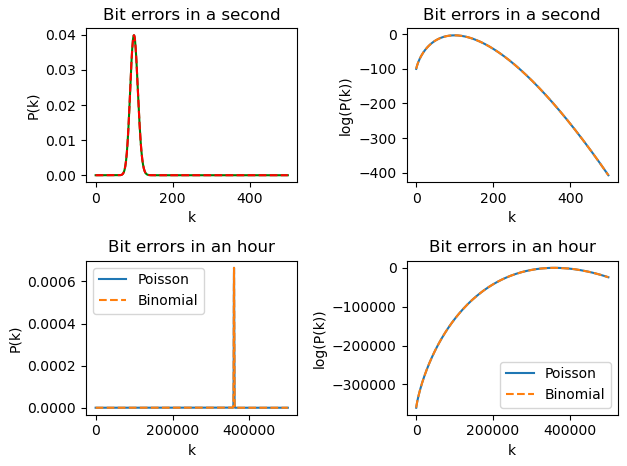 

Here I changed p to be $1*10^{-5}$ so for the 1 second and 1 hour scenario, np is 100,000 and 360,000,000, and just looked at a zoomed in portion of the graph.

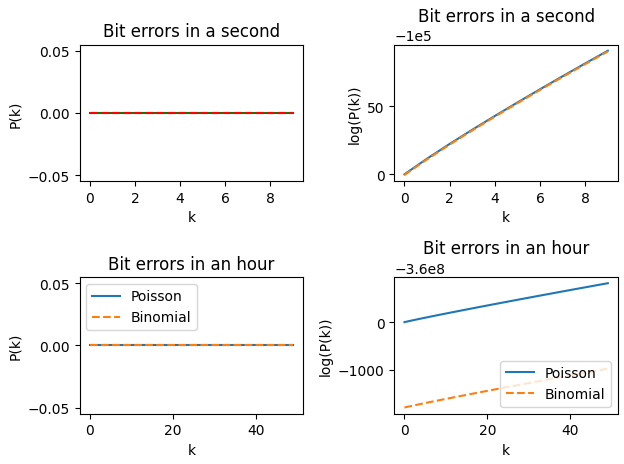

4.7. Compare and contrast the log PMF plots for the Binomial and Poisson distributions in both scenarios. How does the logarithmic scale affect the visualization of probability mass functions?

The logarithmic scale helps us to view the differences between the PMFs that are not visible when we look at it in full scale. In this second scenario where the np assumption is not satisfied, the log plots looks very different (almost linear) but this is just because we are looking at a zoomed in section. If we zoom out they have the same shape as before.

## 4. Distribution of packets received with exponential inter-arrival times
Simulate exponential interarrival times using interarrival_time = np.random.exponential(1 / rate) interarrival_times is a list that stores the time intervals between consecutive events in the Poisson process. Each entry in this list represents the time elapsed between one event and the next. Calculate the time instances where these events are happening using event_times.append(current_time)

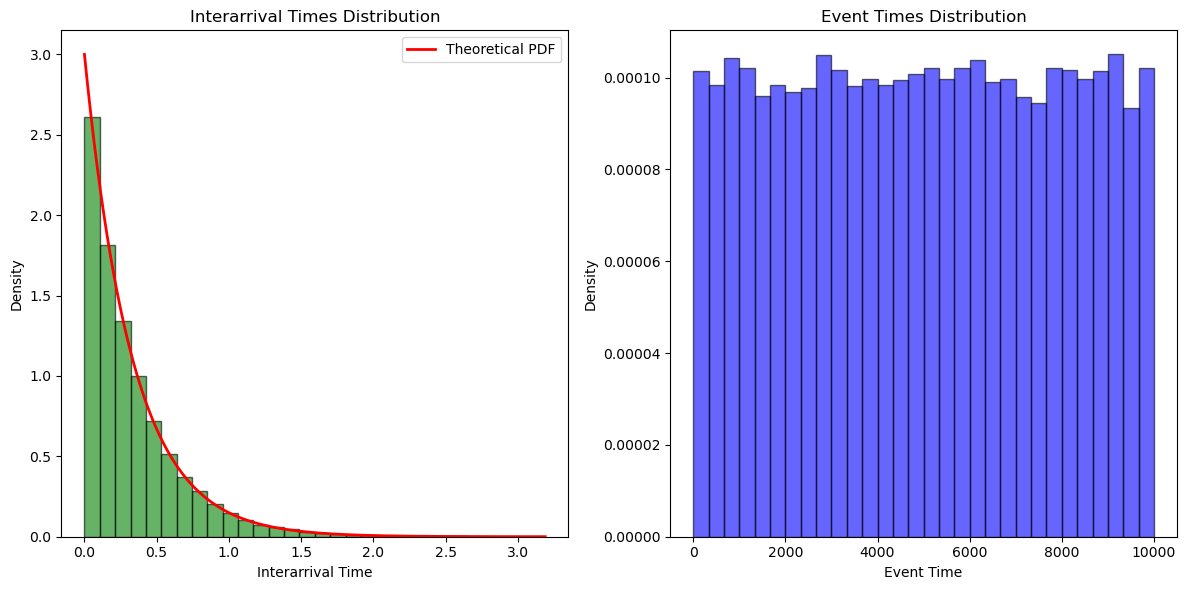

In [215]:
import numpy as np
import matplotlib.pyplot as plt

def Inter_arrival_times(rate, time_limit):
    """
    Simulate a Poisson process given a rate (λ) and time limit.
    
    Parameters:
    rate (float): The rate parameter λ of the exponential distribution.
    time_limit (float): The total time duration to simulate.
    
    Returns:
    event_times (list): The times at which events occur.
    interarrival_times (list): The times between successive events.
    """
    # Initialize lists to store event times and interarrival times
    event_times = []
    interarrival_times = []
    
    # Start the simulation
    current_time = 0
    
    # Generate interarrival times until the time limit is reached
    while current_time < time_limit:
        # Generate the next interarrival time from an exponential distribution
        interarrival_time = np.random.exponential(1 / rate)
        interarrival_times.append(interarrival_time)
        
        # Update the current time and store the event time
        current_time += interarrival_time
        if current_time < time_limit:
            event_times.append(current_time)
    
    return event_times, interarrival_times

# Parameters
rate = 3 # Choose a Rate parameter λ 
time_limit = 10000  # Select a Total time duration to simulate

# Count 
event_times, interarrival_times = Inter_arrival_times(rate, time_limit)

# Plot the results
plt.figure(figsize=(12, 6))

# Plot the interarrival times
plt.subplot(1, 2, 1)
plt.hist(interarrival_times, bins=30, density=True, alpha=0.6, color='g', edgecolor='black')
x = np.linspace(0, max(interarrival_times), 1000)
plt.plot(x, rate * np.exp(-rate * x), 'r-', lw=2, label='Theoretical PDF')
plt.title('Interarrival Times Distribution')
plt.xlabel('Interarrival Time')
plt.ylabel('Density')
plt.legend()

# Plot the event times
plt.subplot(1, 2, 2)
plt.hist(event_times, bins=30, density=True, alpha=0.6, color='b', edgecolor='black')
plt.title('Event Times Distribution')
plt.xlabel('Event Time')
plt.ylabel('Density')


plt.tight_layout()
plt.show()


Exercise questions

Complete code for inputs and generate histograms of plots for the inter-arrival times


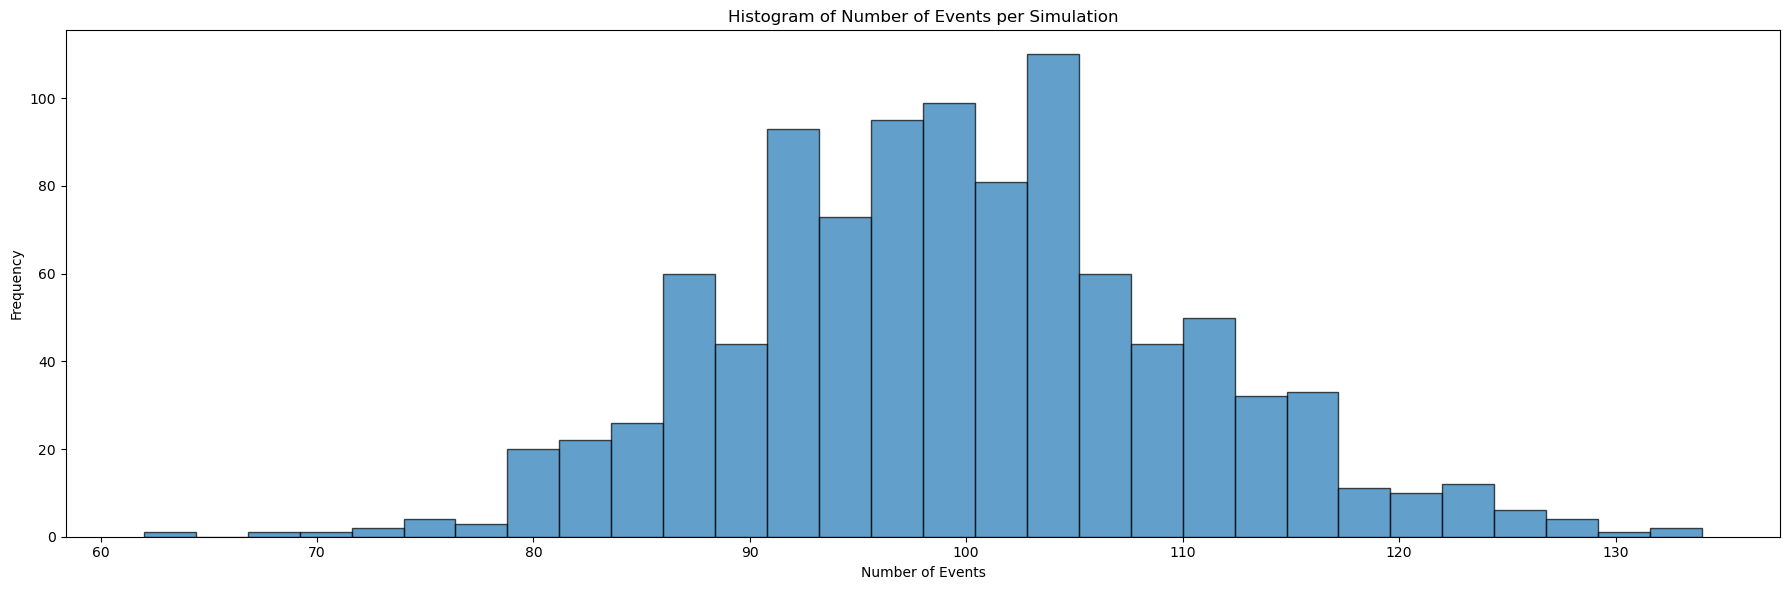

In [221]:
import numpy as np
import matplotlib.pyplot as plt

def inter_arrival_times(rate, time_limit):
    """
    Simulate a Poisson process given a rate (λ) and time limit.

    Parameters:
    rate (float): The rate parameter λ of the exponential distribution.
    time_limit (float): The total time duration to simulate.

    Returns:
    event_times (list): The times at which events occur (t_1, t_2, ... ≤ time_limit).
    interarrival_times (list): The interarrival times actually used (Δ_1, Δ_2, ...).
    """
    event_times = []
    interarrival_times = []
    current_time = 0.0

    while True:
        inter = np.random.exponential(1.0 / rate)
        if current_time + inter > time_limit:
            break  # do not include the overshoot interval
        current_time += inter
        event_times.append(current_time)
        interarrival_times.append(inter)

    return event_times, interarrival_times


def simulate_multiple_processes(rate, time_limit, num_simulations):
    """
    Simulate multiple Poisson processes and return the number of events in each simulation.
    """
    num_events_list = []
    for _ in range(num_simulations):
        event_times, _ = inter_arrival_times(rate, time_limit)
        num_events_list.append(len(event_times))
    return num_events_list


# Parameters
TI = 0.01    #Choose time slot =1, 0.1, 0.01
rate = 1.0 / TI  # Rate λ
time_limit = 1
num_simulations = 1000

# Simulate one process (for plots 1 & 2) and many (for plot 3)
one_event_times, one_interarrival_times = inter_arrival_times(rate, time_limit)
num_events_list = simulate_multiple_processes(rate, time_limit, num_simulations)

# Plotting
plt.figure(figsize=(18, 6))

# 3) Histogram of number of events across simulations

plt.hist(num_events_list, bins=30, edgecolor='black', alpha=0.7)
plt.title('Histogram of Number of Events per Simulation')
plt.xlabel('Number of Events')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


In [213]:
np.mean(num_events_list)

100.168

In [133]:
np.var(num_events_list)

99.32577599999999